# WM-811K wafer maps — real-data case study

The simulation study controls the rare-class calibration count and guarantees
exact invariance by construction. Neither holds here, and that is the point:
this notebook asks whether the two assumptions the theory rests on survive when
they are not imposed by design.

**What the theory predicts.** Conformal validity does not require invariance.
Conditionally on the group elements, both the orbit-averaged and the
prediction-averaged score are fixed measurable functions of the observation, so
coverage holds whether or not the group preserves the class. Invariance is what
licenses reading orbit averaging as variance reduction. Approximate invariance
should therefore show up in efficiency and not in coverage — a falsifiable
prediction, tested here.

**Design.**

| | |
|---|---|
| models | EfficientNet-B0, CNN, each fitted once |
| scores | APS, TTA-Avg, orbit-averaged APS |
| baselines | marginal APS, clustered conformal prediction |
| ablation | naive multi-copy calibration |
| calibration | marginal and classwise |
| group | $D_4$ (8 elements) |
| nominal levels | 0.10 and 0.01 |
| replications | 300 calibration/test splits |

The two nominal levels place the problem on opposite sides of the finite-sample
boundary: a finite classwise threshold needs $\lceil(1-\alpha)/\alpha\rceil$
calibration observations in the class, which is 9 at $\alpha=0.10$ and 99 at
$\alpha=0.01$. The comparison exercises on real data the regime transition the
simulations identify.

**Limit of the design, stated rather than glossed.** Each architecture is fitted
once, so the reported variability is that of calibration and of the score
randomisation, not of the whole pipeline. Whether the sign of the efficiency
effect is stable within an architecture, as opposed to a property of the
particular fitted model, would require refitting under several seeds.

## 1. Setup

In [3]:
from google.colab import drive
drive.mount("/content/drive")

BASE        = "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation"
CODE_DIR    = f"{BASE}/csda_revision/code"
DATA_DIR    = f"{BASE}/WMDD_application/dataset"          # wafer maps and fitted models
RESULTS_DIR = f"{BASE}/WMDD_application/results_revision"

import sys, os
sys.path.insert(0, CODE_DIR)
os.makedirs(RESULTS_DIR, exist_ok=True)

import numpy as np, pandas as pd
import metrics as M
import calibration as cal
from scores import (aps_scores, draw_uniform, prediction_averaged_scores,
                    score_averaged_scores, within_orbit_score_variance)
from image_groups import DihedralGroup

pd.set_option("display.width", 220); pd.set_option("display.max_rows", 200)
print("metrics", getattr(M, "__version__", "unknown"))

# Order must match cfg.label2int in the export notebooks: the columns of
# probs.npy follow it, and getting it wrong silently permutes every per-class
# figure while leaving the aggregates intact.
CLASSES = ["Center", "Donut", "Edge-Loc", "Edge-Ring",
           "Loc", "Random", "Scratch", "Near-full"]
K = len(CLASSES)

# Whether a rotation or a reflection plausibly preserves the class.
RADIAL      = ["Center", "Donut", "Edge-Ring", "Random", "Near-full"]
DIRECTIONAL = ["Edge-Loc", "Loc", "Scratch"]

ALPHAS   = [0.10, 0.01]
MODELS = ["coat_tiny", "tf_efficientnet_b0_ns", "cnn"]   # file prefixes in DATA_DIR
ALLOW_MISSING = False    # True only for exploratory runs: missing models are skipped

CAL_FRAC = 0.5          # of the held-out set; the rest is the test set
R        = 300
BASE_SEED = 20260808

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
metrics 2026-08-rev3


## 2. Model outputs

The classifier is fitted once, so what this notebook needs is not the images and
the network but their outputs: the predicted probabilities for every held-out
wafer under every group element. The eight forward passes were done once in the
export notebooks; the replications below resample splits of an array already in
memory.

In [4]:
MODELS = ["coat_tiny", "tf_efficientnet_b0_ns", 'resnext50_32x4d', "cnn"]   # file prefixes in DATA_DIR
ALLOW_MISSING = False    # True only for exploratory runs: missing models are skipped

GROUP = DihedralGroup(include_reflections=True)   # D4: 8 elements


def load_model_outputs(name):
    p = np.load(f"{DATA_DIR}/{name}_probs.npy")
    y = np.load(f"{DATA_DIR}/{name}_labels.npy")
    assert p.ndim == 3, f"{name}: expected (|G|, n, K), got {p.shape}"
    assert p.shape[0] == GROUP.size, f"{name}: expected {GROUP.size} group elements, got {p.shape[0]}"
    assert p.shape[1:] == (y.shape[0], K), f"{name}: probs {p.shape} vs labels {y.shape}, K={K}"
    assert np.allclose(p.sum(axis=2), 1.0, atol=1e-4), f"{name}: probabilities do not sum to one"

    # Written by the export notebook; absent for arrays exported elsewhere.
    meta_file = f"{DATA_DIR}/{name}_meta.json"
    if os.path.isfile(meta_file):
        with open(meta_file) as fh:
            meta = json.load(fh)
        assert meta["group_size"] == GROUP.size, f"{name}: exported with |G| = {meta['group_size']}"
        order = sorted(meta["label2int"], key=meta["label2int"].get)
        assert order == list(CLASSES), f"{name}: class order {order} differs from CLASSES"
    return p, y


outputs, missing = {}, []
w = max(map(len, MODELS))
for name in MODELS:
    try:
        outputs[name] = load_model_outputs(name)
    except FileNotFoundError:
        missing.append(name)
        print(f"{name:{w}s}  not found in {DATA_DIR}")
        continue
    p, y = outputs[name]
    print(f"{name:{w}s}  {p.shape[1]:>6} wafers | accuracy {(p[0].argmax(1) == y).mean():.3f}")

if missing and not ALLOW_MISSING:
    raise FileNotFoundError(f"missing exports in {DATA_DIR}: {missing}")
if not outputs:
    raise FileNotFoundError(f"no model found in {DATA_DIR}")
MODELS = list(outputs)          # downstream cells use the models actually loaded

# All models share the held-out set, so the labels must agree.
ref = MODELS[0]
labels_ref = outputs[ref][1]
for name in MODELS[1:]:
    assert np.array_equal(outputs[name][1], labels_ref), \
        f"{name} and {ref} were exported on different held-out sets"

counts = pd.Series(np.bincount(labels_ref, minlength=K), index=CLASSES, name="held out")
display(counts.to_frame().T)

coat_tiny                3649 wafers | accuracy 0.935
tf_efficientnet_b0_ns    3649 wafers | accuracy 0.919
resnext50_32x4d          3649 wafers | accuracy 0.924
cnn                      3649 wafers | accuracy 0.828


,Center,Donut,Edge-Loc,Edge-Ring,Loc,Random,Scratch,Near-full
held out,615,148,635,1389,413,203,202,44


In [5]:
GROUP = DihedralGroup(include_reflections=True)   # D4: 8 elements

def load_model_outputs(name):
    p = np.load(f"{DATA_DIR}/{name}_probs.npy")
    y = np.load(f"{DATA_DIR}/{name}_labels.npy")
    assert p.shape[0] == GROUP.size, f"expected 8 group elements, got {p.shape[0]}"
    assert p.shape[1] == y.shape[0] and p.shape[2] == K
    assert np.allclose(p.sum(axis=2), 1.0, atol=1e-4), "probabilities do not sum to one"
    return p, y

outputs = {}
for name in MODELS:
    try:
        outputs[name] = load_model_outputs(name)
        p, y = outputs[name]
        print(f"{name:18s} {p.shape[1]:>6} wafers | accuracy {(p[0].argmax(1) == y).mean():.3f}")
    except FileNotFoundError:
        print(f"{name:18s} not found in {DATA_DIR}")

# The two models share the held-out set, so the labels must agree.
if len(outputs) == 2:
    assert np.array_equal(outputs[MODELS[0]][1], outputs[MODELS[1]][1]), \
        "the two models were exported on different held-out sets"

labels_ref = outputs[MODELS[0]][1]
counts = pd.Series(np.bincount(labels_ref, minlength=K), index=CLASSES, name="held out")
display(counts.to_frame().T)

coat_tiny            3649 wafers | accuracy 0.935
tf_efficientnet_b0_ns   3649 wafers | accuracy 0.919
resnext50_32x4d      3649 wafers | accuracy 0.924
cnn                  3649 wafers | accuracy 0.828


,Center,Donut,Edge-Loc,Edge-Ring,Loc,Random,Scratch,Near-full
held out,615,148,635,1389,413,203,202,44


## 3. Class counts and the finite-threshold boundary

The rarest class decides whether classwise calibration is usable at all. This
table says which classes are expected to fall below $n_y^{\min}$ at each
nominal level, before any calibration is run.

In [6]:
exp_cal = (counts * CAL_FRAC).round().astype(int)
tab = pd.DataFrame({"held out": counts, "expected calibration": exp_cal})
for a in ALPHAS:
    tab[f"below n_min (a={a})"] = exp_cal < M.finite_threshold_min(a)
display(tab)

for a in ALPHAS:
    nmin = M.finite_threshold_min(a)
    below = list(tab.index[exp_cal < nmin])
    print(f"alpha={a}: n_min={nmin:>3} | classes expected below: {below if below else 'none'}")

,held out,expected calibration,below n_min (a=0.1),below n_min (a=0.01)
Center,615,308,False,False
Donut,148,74,False,True
Edge-Loc,635,318,False,False
Edge-Ring,1389,694,False,False
Loc,413,206,False,False
Random,203,102,False,False
Scratch,202,101,False,False
Near-full,44,22,False,True


alpha=0.1: n_min=  9 | classes expected below: none
alpha=0.01: n_min= 99 | classes expected below: ['Donut', 'Near-full']


## 4. Replications

Each replication draws a fresh calibration/test split of the held-out set and
fresh APS randomisation variables from separate streams, then recalibrates every
arm. The classifier and the group elements are fixed.

The split is a plain random draw, not stratified: stratifying to fixed per-class
counts would leave the calibration points non-exchangeable with the test point
and would remove the very variability being measured.

The same split and the same randomisation are used by every arm within a
replication, so all comparisons below are paired.

In [7]:
def run_replication(probs, labels, rep, alpha, cal_frac=CAL_FRAC):
    """One calibration/test split; every score and calibration arm."""
    orb = probs

    rng_split, rng_ucal, rng_utest = (
        np.random.default_rng(s)
        for s in np.random.SeedSequence([BASE_SEED, rep]).spawn(3))

    idx = rng_split.permutation(len(labels))
    n_cal = int(round(cal_frac * len(labels)))
    ca, te = idx[:n_cal], idx[n_cal:]

    U_ca = draw_uniform(len(ca), K, rng_ucal)
    U_te = draw_uniform(len(te), K, rng_utest)
    orb_ca, orb_te = orb[:, ca, :], orb[:, te, :]
    y_ca, y_te = labels[ca], labels[te]

    arms = {
        "plain":    (aps_scores(orb_ca[0], U_ca), aps_scores(orb_te[0], U_te)),
        "ttaavg":   (prediction_averaged_scores(orb_ca, U_ca),
                     prediction_averaged_scores(orb_te, U_te)),
        "orbitavg": (score_averaged_scores(orb_ca, U_ca),
                     score_averaged_scores(orb_te, U_te)),
    }

    built = []
    for score_name, (s_ca, s_te) in arms.items():
        sets, _ = cal.marginal_sets(s_ca, y_ca, s_te, alpha)
        built.append((f"marginal_{score_name}", "marginal", sets, 0))
        sets, q = cal.classwise_sets(s_ca, y_ca, s_te, alpha, K)
        built.append((f"classwise_{score_name}", "class-conditional", sets,
                      int(np.isinf(q).sum())))

    # Naive multi-copy: every transformed copy of a calibration wafer enters as
    # its own calibration unit, so the classwise quantile is taken over
    # |G| * n_y values. This is the augmented method of the submitted version.
    # It carries no finite-sample guarantee: the copies are deterministic
    # functions of one observation, and replacing n_y by |G| * n_y places the
    # threshold at a relatively lower order statistic than the correction
    # requires, so the procedure is systematically less conservative. It is
    # reported to measure that effect rather than to assume it, and because
    # below the finite-sample boundary it restores finite thresholds where the
    # valid classwise procedure returns none.
    aug_scores = np.vstack([aps_scores(orb_ca[b], U_ca) for b in range(GROUP.size)])
    aug_labels = np.tile(y_ca, GROUP.size)
    sets, q = cal.classwise_sets(aug_scores, aug_labels, arms["plain"][1], alpha, K)
    built.append(("naive_multicopy", "none", sets, int(np.isinf(q).sum())))

    # Clustered conformal prediction, on the plain APS score. It is a baseline
    # with a weaker, cluster-conditional target, not an arm of the comparison
    # among score constructions, so it is not given the averaged score. Whether
    # its clustering step runs at all is governed by the tuning heuristic of
    # Ding et al., which was calibrated for problems with 100 to 1000 classes.
    sets = cal.clustered_sets(arms["plain"][0], y_ca, arms["plain"][1], y_te,
                              alpha, seed=BASE_SEED + rep)
    built.append(("clustered", "cluster-conditional", sets, 0))

    wov = within_orbit_score_variance(orb_te, y_te, U_te)
    cal_counts = np.bincount(y_ca, minlength=K)

    rows = []
    for method, guarantee, sets, n_inf in built:
        cov, size = sets[np.arange(len(y_te)), y_te], sets.sum(1)
        base = dict(rep=rep, alpha=alpha,
                    method=method, guarantee=guarantee, n_infinite_qhat=n_inf,
                    coverage_marginal=float(cov.mean()),
                    avg_size_marginal=float(size.mean()),
                    var_within_orbit=float(wov.mean()))
        for c in range(K):
            m = y_te == c
            rows.append({**base, "cls": c, "class_name": CLASSES[c],
                         "n_cal_cls": int(cal_counts[c]),
                         "n_test_cls": int(m.sum()),
                         "coverage_cls": float(cov[m].mean()),
                         "avg_size_cls": float(size[m].mean()),
                         "var_within_orbit_cls": float(wov[m].mean())})
    return rows


frames = []
for name, (probs, labels) in outputs.items():
    for alpha in ALPHAS:
        rows = [r for rep in range(R)
                for r in run_replication(probs, labels, rep, alpha)]
        frames.append(pd.DataFrame(rows).assign(model=name))
        print(f"[{name} | alpha={alpha}] done", flush=True)

real = pd.concat(frames, ignore_index=True)
real.to_parquet(f"{RESULTS_DIR}/real_long.parquet")
print(f"\n{len(real):,} rows written")

[coat_tiny | alpha=0.1] done
[coat_tiny | alpha=0.01] done
[tf_efficientnet_b0_ns | alpha=0.1] done
[tf_efficientnet_b0_ns | alpha=0.01] done
[resnext50_32x4d | alpha=0.1] done
[resnext50_32x4d | alpha=0.01] done
[cnn | alpha=0.1] done
[cnn | alpha=0.01] done

153,600 rows written


## 5. Summary

Per-replication metrics first, then averaged across replications with their
Monte Carlo standard error. Set sizes are not compared across models: they
depend on predictive accuracy, and the two networks differ substantially on
that.

In [8]:
def per_replication(d):
    dev = d.coverage_cls - (1 - d.alpha)
    w = d.assign(_abs=dev.abs(), _und=(-dev).clip(lower=0))
    return (w.groupby(["model", "alpha", "method", "guarantee", "rep"],
                      observed=True)
              .agg(MCCD=("_abs", "mean"), WCU=("_und", "max"),
                   AvgSize=("avg_size_marginal", "first"),
                   MacroSize=("avg_size_cls", "mean"),
                   CovMarginal=("coverage_marginal", "first"),
                   n_inf=("n_infinite_qhat", "first"))
              .reset_index())

def mcse(s):
    return float(s.std(ddof=1) / np.sqrt(len(s)))

rep = per_replication(real)
summ = (rep.groupby(["model", "alpha", "method", "guarantee"], observed=True)
           .agg(WCU=("WCU", "mean"), WCU_mcse=("WCU", mcse),
                MCCD=("MCCD", "mean"),
                AvgSize=("AvgSize", "mean"), AvgSize_mcse=("AvgSize", mcse),
                MacroSize=("MacroSize", "mean"),
                CovMarginal=("CovMarginal", "mean"),
                n_inf=("n_inf", "mean"), n_rep=("WCU", "size"))
           .reset_index())

# Everything is computed, marginal arms included; only the arms that target
# class-conditional coverage, plus the naive scheme, are displayed. The marginal
# arms pursue a different guarantee, so comparing their set sizes with the
# classwise ones is not like-for-like; they are kept for the appendix and as a
# check that marginal coverage sits at the nominal level.
main = summ
display(main[main.guarantee.isin(["class-conditional",
                                  "cluster-conditional", "none"])]
        .round({"WCU": 4, "WCU_mcse": 4, "MCCD": 4, "AvgSize": 3,
                "AvgSize_mcse": 3, "MacroSize": 3, "CovMarginal": 4,
                "n_inf": 2}))

# Design check: the marginal arms must attain the nominal level.
chk = main[main.guarantee == "marginal"]
for a in sorted(chk.alpha.unique()):
    s_ = chk[chk.alpha == a]
    print(f"alpha={a}: marginal coverage {s_.CovMarginal.min():.4f} - "
          f"{s_.CovMarginal.max():.4f} (nominal {1 - a:.2f})")

summ.to_csv(f"{RESULTS_DIR}/real_summary.csv", index=False)

,model,alpha,method,guarantee,WCU,WCU_mcse,MCCD,AvgSize,AvgSize_mcse,MacroSize,CovMarginal,n_inf,n_rep
0,cnn,0.01,classwise_orbitavg,class-conditional,0.0122,0.0008,0.0081,4.572,0.031,4.687,0.9917,2.72,300
1,cnn,0.01,classwise_plain,class-conditional,0.0117,0.0007,0.0080,4.739,0.030,5.285,0.9918,2.72,300
2,cnn,0.01,classwise_ttaavg,class-conditional,0.0119,0.0007,0.0081,4.591,0.030,4.718,0.9918,2.72,300
3,cnn,0.01,clustered,cluster-conditional,0.0340,0.0009,0.0103,2.304,0.005,3.231,0.9903,0.00,300
7,cnn,0.01,naive_multicopy,none,0.0166,0.0013,0.0083,2.515,0.005,3.737,0.9923,0.00,300
8,cnn,0.10,classwise_orbitavg,class-conditional,0.0579,0.0027,0.0305,1.400,0.002,1.670,0.9024,0.00,300
9,cnn,0.10,classwise_plain,class-conditional,0.0592,0.0029,0.0306,1.419,0.002,1.707,0.9024,0.00,300
10,cnn,0.10,classwise_ttaavg,class-conditional,0.0561,0.0025,0.0302,1.418,0.002,1.692,0.9025,0.00,300
11,cnn,0.10,clustered,cluster-conditional,0.0262,0.0010,0.0302,1.408,0.002,1.713,0.9009,0.00,300
15,cnn,0.10,naive_multicopy,none,0.0595,0.0035,0.0295,1.430,0.002,1.715,0.9058,0.00,300


alpha=0.01: marginal coverage 0.9899 - 0.9903 (nominal 0.99)
alpha=0.1: marginal coverage 0.8998 - 0.9011 (nominal 0.90)


### Paired comparisons

Within a replication the arms share the split, the fitted model, the group
elements and the randomisation, so differencing isolates the score
construction. The paired standard error is far smaller than the two marginal
ones suggest.

In [9]:
def paired(rep_df, model, alpha, metric, a, b):
    s = rep_df[(rep_df.model == model) & (rep_df.alpha == alpha)]
    x = s[s.method == a].set_index("rep")[metric]
    z = s[s.method == b].set_index("rep")[metric]
    d = (z - x).dropna()
    if len(d) == 0:
        return None
    # A relative change is meaningful for a size, not for a coverage metric
    # that can be exactly zero in a replication.
    pct = float(100 * (x - z).div(x).mean()) if metric == "AvgSize" else np.nan
    return dict(model=model, alpha=alpha, metric=metric,
                comparison=f"{b} vs {a}", mean_delta=float(d.mean()),
                mcse=mcse(d), pct=pct,
                frac_negative=float((d < 0).mean()), n=len(d))

COMPARISONS = [("classwise_plain",  "classwise_orbitavg"),
               ("classwise_plain",  "classwise_ttaavg"),
               ("classwise_ttaavg", "classwise_orbitavg")]

pairs = pd.DataFrame([r for m in outputs for a in ALPHAS
                      for x, z in COMPARISONS for k in ("AvgSize", "WCU")
                      if (r := paired(rep, m, a, k, x, z)) is not None])
pairs["t"] = pairs.mean_delta / pairs.mcse
display(pairs.round(4))
print("mean_delta is the second arm minus the first; negative favours the second.")
pairs.to_csv(f"{RESULTS_DIR}/real_paired.csv", index=False)

,model,alpha,metric,comparison,mean_delta,mcse,pct,frac_negative,n,t
0,coat_tiny,0.10,AvgSize,classwise_orbitavg vs classwise_plain,0.0181,0.0007,-1.7332,0.0633,300,26.4107
1,coat_tiny,0.10,WCU,classwise_orbitavg vs classwise_plain,-0.0012,0.0015,NaN,0.4067,300,-0.7512
2,coat_tiny,0.10,AvgSize,classwise_ttaavg vs classwise_plain,0.0111,0.0006,-1.0635,0.1633,300,17.1615
3,coat_tiny,0.10,WCU,classwise_ttaavg vs classwise_plain,-0.0022,0.0015,NaN,0.4300,300,-1.4723
4,coat_tiny,0.10,AvgSize,classwise_orbitavg vs classwise_ttaavg,0.0070,0.0004,-0.6644,0.1667,300,16.5386
5,coat_tiny,0.10,WCU,classwise_orbitavg vs classwise_ttaavg,0.0011,0.0012,NaN,0.3567,300,0.8795
6,coat_tiny,0.01,AvgSize,classwise_orbitavg vs classwise_plain,-0.0712,0.0051,1.7859,0.7933,300,-14.0906
7,coat_tiny,0.01,WCU,classwise_orbitavg vs classwise_plain,-0.0004,0.0006,NaN,0.4533,300,-0.7237
8,coat_tiny,0.01,AvgSize,classwise_ttaavg vs classwise_plain,-0.0505,0.0052,1.2756,0.6933,300,-9.7951
9,coat_tiny,0.01,WCU,classwise_ttaavg vs classwise_plain,-0.0005,0.0006,NaN,0.4467,300,-0.8564


mean_delta is the second arm minus the first; negative favours the second.


### The naive multi-copy scheme

The method proposed in the submitted version treated the transformed copies as
additional calibration units. The revision shows that this forfeits the
finite-sample guarantee, so it is reported here as an ablation rather than as a
competitor.

It is worth reporting, and not only for continuity. Below the finite-sample
boundary the valid classwise procedure returns an infinite threshold: the class
enters every prediction set and the output carries no information. Multiplying
the calibration units by the group size restores a finite threshold, at the cost
of a correction that presumes more exchangeable observations than are available.
In a deployment constrained by labelled data that trade may be worth making
explicitly, as a way of starting while more data are collected, provided the
absence of a guarantee is stated rather than implied.

The table below quantifies the trade at both nominal levels: how many classes
recover a finite threshold, what happens to set size, and what it costs in
coverage on the classes whose thresholds were restored.

In [18]:
naive = (main[main.method.isin(["classwise_plain", "classwise_orbitavg",
                                "naive_multicopy"])]
         [["model", "alpha", "method", "WCU", "WCU_mcse", "AvgSize",
           "CovMarginal", "n_inf"]])
display(naive.round({"WCU": 4, "WCU_mcse": 4, "AvgSize": 3,
                     "CovMarginal": 4, "n_inf": 2})
        .sort_values(["model", "alpha", "method"]))

# Paired comparison against the valid classwise procedure.
def paired(m, a, arm1, arm2, metric):
    s = rep[(rep.model == m) & (rep.alpha == a)]
    x = s[s.method == arm1].set_index("rep")[metric]
    y = s[s.method == arm2].set_index("rep")[metric]
    d = (x - y).dropna()
    se = d.std(ddof=1) / np.sqrt(len(d))
    return {"model": m, "alpha": a, "metric": metric,
            "comparison": f"{arm1} vs {arm2}",
            "mean_delta": d.mean(), "mcse": se, "t": d.mean() / se,
            "frac_negative": float((d < 0).mean()), "n": len(d)}

naive_paired = pd.DataFrame(
    [paired(m, a, "naive_multicopy", "classwise_plain", met)
     for m in outputs for a in ALPHAS for met in ["WCU", "AvgSize"]])
display(naive_paired.round(4).sort_values(["metric", "model", "alpha"]))
print("mean_delta is the first arm minus the second: positive WCU favours classwise APS, "
      "negative AvgSize favours the naive scheme.")

# Which classes recover a finite threshold, and at what cost in coverage.
naive_cls = (real[real.method.isin(["classwise_plain", "naive_multicopy"])]
             .groupby(["model", "alpha", "method", "class_name"], observed=True)
             .agg(n_cal=("n_cal_cls", "mean"),
                  coverage=("coverage_cls", "mean"),
                  avg_size=("avg_size_cls", "mean"))
             .reset_index())
naive_cls["below_n_min"] = naive_cls.apply(
    lambda r: r.n_cal < M.finite_threshold_min(r.alpha), axis=1)

# Only the classes the valid procedure cannot calibrate are informative here.
restored = naive_cls[naive_cls.below_n_min]
if len(restored):
    print("\nClasses below the boundary for the valid classwise procedure:")
    display(restored.round(3).sort_values(["model", "alpha", "class_name"]))
else:
    print("\nNo class falls below the boundary at either nominal level, "
          "so the naive scheme restores nothing that was missing.")

# How many classes fall below the nominal level, and whether they are the degenerate ones.
below_rows = []
for (m, a, meth), s in naive_cls.groupby(["model", "alpha", "method"], observed=True):
    below = s[s.coverage < 1 - a]
    below_rows.append({
        "model": m, "alpha": a, "method": meth,
        "n_below": len(below),
        "of_which_degenerate": int(below.below_n_min.sum()),
        "min_coverage": float(s.coverage.min()),
        "worst_class": s.loc[s.coverage.idxmin(), "class_name"],
        "classes_below": ", ".join(below.sort_values("coverage").class_name),
    })
below_nominal = pd.DataFrame(below_rows)
print("\nClasses below the nominal level:")
display(below_nominal.round(4).sort_values(["model", "alpha", "method"]))

naive_cls.to_csv(f"{RESULTS_DIR}/real_naive_per_class.csv", index=False)
naive_paired.to_csv(f"{RESULTS_DIR}/real_naive_paired.csv", index=False)
below_nominal.to_csv(f"{RESULTS_DIR}/real_naive_below_nominal.csv", index=False)

,model,alpha,method,WCU,WCU_mcse,AvgSize,CovMarginal,n_inf
0,cnn,0.01,classwise_orbitavg,0.0122,0.0008,4.572,0.9917,2.72
1,cnn,0.01,classwise_plain,0.0117,0.0007,4.739,0.9918,2.72
7,cnn,0.01,naive_multicopy,0.0166,0.0013,2.515,0.9923,0.00
8,cnn,0.10,classwise_orbitavg,0.0579,0.0027,1.400,0.9024,0.00
9,cnn,0.10,classwise_plain,0.0592,0.0029,1.419,0.9024,0.00
15,cnn,0.10,naive_multicopy,0.0595,0.0035,1.430,0.9058,0.00
16,coat_tiny,0.01,classwise_orbitavg,0.0108,0.0006,4.117,0.9918,2.72
17,coat_tiny,0.01,classwise_plain,0.0112,0.0007,4.188,0.9917,2.72
23,coat_tiny,0.01,naive_multicopy,0.0512,0.0030,1.541,0.9888,0.00
24,coat_tiny,0.10,classwise_orbitavg,0.0599,0.0026,1.067,0.9018,0.00


,model,alpha,metric,comparison,mean_delta,mcse,t,frac_negative,n
15,cnn,0.01,AvgSize,naive_multicopy vs classwise_plain,-2.2236,0.0292,-76.2118,1.0000,300
13,cnn,0.10,AvgSize,naive_multicopy vs classwise_plain,0.0115,0.0012,9.5503,0.3000,300
3,coat_tiny,0.01,AvgSize,naive_multicopy vs classwise_plain,-2.6465,0.0315,-83.9690,1.0000,300
1,coat_tiny,0.10,AvgSize,naive_multicopy vs classwise_plain,-0.0037,0.0004,-8.4016,0.6700,300
11,resnext50_32x4d,0.01,AvgSize,naive_multicopy vs classwise_plain,-2.2173,0.0305,-72.6286,1.0000,300
9,resnext50_32x4d,0.10,AvgSize,naive_multicopy vs classwise_plain,0.0172,0.0008,20.2833,0.1033,300
7,tf_efficientnet_b0_ns,0.01,AvgSize,naive_multicopy vs classwise_plain,-2.6581,0.0333,-79.9024,1.0000,300
5,tf_efficientnet_b0_ns,0.10,AvgSize,naive_multicopy vs classwise_plain,-0.0085,0.0006,-13.2844,0.7600,300
14,cnn,0.01,WCU,naive_multicopy vs classwise_plain,0.0050,0.0014,3.4512,0.3733,300
12,cnn,0.10,WCU,naive_multicopy vs classwise_plain,0.0003,0.0023,0.1366,0.4333,300


mean_delta is the first arm minus the second: positive WCU favours classwise APS, negative AvgSize favours the naive scheme.

Classes below the boundary for the valid classwise procedure:


,model,alpha,method,class_name,n_cal,coverage,avg_size,below_n_min
1,cnn,0.01,classwise_plain,Donut,73.867,1.000,4.210,True
9,cnn,0.01,naive_multicopy,Donut,73.867,0.991,2.913,True
5,cnn,0.01,classwise_plain,Near-full,21.950,1.000,6.354,True
13,cnn,0.01,naive_multicopy,Near-full,21.950,0.993,6.646,True
33,coat_tiny,0.01,classwise_plain,Donut,73.867,1.000,4.007,True
41,coat_tiny,0.01,naive_multicopy,Donut,73.867,0.989,2.145,True
37,coat_tiny,0.01,classwise_plain,Near-full,21.950,1.000,3.820,True
45,coat_tiny,0.01,naive_multicopy,Near-full,21.950,0.952,2.054,True
65,resnext50_32x4d,0.01,classwise_plain,Donut,73.867,1.000,4.058,True
73,resnext50_32x4d,0.01,naive_multicopy,Donut,73.867,0.982,2.782,True



Classes below the nominal level:


,model,alpha,method,n_below,of_which_degenerate,min_coverage,worst_class,classes_below
0,cnn,0.01,classwise_plain,0,0,0.9906,Edge-Ring,
1,cnn,0.01,naive_multicopy,2,0,0.9865,Scratch,"Scratch, Edge-Loc"
2,cnn,0.10,classwise_plain,0,0,0.9003,Edge-Loc,
3,cnn,0.10,naive_multicopy,2,0,0.8970,Edge-Loc,"Edge-Loc, Donut"
4,coat_tiny,0.01,classwise_plain,0,0,0.9907,Edge-Ring,
5,coat_tiny,0.01,naive_multicopy,7,2,0.9525,Near-full,"Near-full, Random, Center, Donut, Edge-Loc, Ed..."
6,coat_tiny,0.10,classwise_plain,0,0,0.9008,Loc,
7,coat_tiny,0.10,naive_multicopy,5,0,0.8845,Near-full,"Near-full, Random, Center, Edge-Ring, Donut"
8,resnext50_32x4d,0.01,classwise_plain,0,0,0.9904,Edge-Ring,
9,resnext50_32x4d,0.01,naive_multicopy,3,2,0.9767,Near-full,"Near-full, Donut, Edge-Loc"


In [10]:
naive = (main[main.method.isin(["classwise_plain", "classwise_orbitavg",
                                "naive_multicopy"])]
         [["model", "alpha", "method", "WCU", "WCU_mcse", "AvgSize",
           "CovMarginal", "n_inf"]])
display(naive.round({"WCU": 4, "WCU_mcse": 4, "AvgSize": 3,
                     "CovMarginal": 4, "n_inf": 2})
        .sort_values(["model", "alpha", "method"]))

# Which classes recover a finite threshold, and at what cost in coverage.
naive_cls = (real[real.method.isin(["classwise_plain", "naive_multicopy"])]
             .groupby(["model", "alpha", "method", "class_name"], observed=True)
             .agg(n_cal=("n_cal_cls", "mean"),
                  coverage=("coverage_cls", "mean"),
                  avg_size=("avg_size_cls", "mean"))
             .reset_index())
naive_cls["below_n_min"] = naive_cls.apply(
    lambda r: r.n_cal < M.finite_threshold_min(r.alpha), axis=1)

# Only the classes the valid procedure cannot calibrate are informative here.
restored = naive_cls[naive_cls.below_n_min]
if len(restored):
    print("Classes below the boundary for the valid classwise procedure:")
    display(restored.round(3).sort_values(["model", "alpha", "class_name"]))
else:
    print("No class falls below the boundary at either nominal level, "
          "so the naive scheme restores nothing that was missing.")

naive_cls.to_csv(f"{RESULTS_DIR}/real_naive_per_class.csv", index=False)

,model,alpha,method,WCU,WCU_mcse,AvgSize,CovMarginal,n_inf
0,cnn,0.01,classwise_orbitavg,0.0122,0.0008,4.572,0.9917,2.72
1,cnn,0.01,classwise_plain,0.0117,0.0007,4.739,0.9918,2.72
7,cnn,0.01,naive_multicopy,0.0166,0.0013,2.515,0.9923,0.00
8,cnn,0.10,classwise_orbitavg,0.0579,0.0027,1.400,0.9024,0.00
9,cnn,0.10,classwise_plain,0.0592,0.0029,1.419,0.9024,0.00
15,cnn,0.10,naive_multicopy,0.0595,0.0035,1.430,0.9058,0.00
16,coat_tiny,0.01,classwise_orbitavg,0.0108,0.0006,4.117,0.9918,2.72
17,coat_tiny,0.01,classwise_plain,0.0112,0.0007,4.188,0.9917,2.72
23,coat_tiny,0.01,naive_multicopy,0.0512,0.0030,1.541,0.9888,0.00
24,coat_tiny,0.10,classwise_orbitavg,0.0599,0.0026,1.067,0.9018,0.00


Classes below the boundary for the valid classwise procedure:


,model,alpha,method,class_name,n_cal,coverage,avg_size,below_n_min
1,cnn,0.01,classwise_plain,Donut,73.867,1.000,4.210,True
9,cnn,0.01,naive_multicopy,Donut,73.867,0.991,2.913,True
5,cnn,0.01,classwise_plain,Near-full,21.950,1.000,6.354,True
13,cnn,0.01,naive_multicopy,Near-full,21.950,0.993,6.646,True
33,coat_tiny,0.01,classwise_plain,Donut,73.867,1.000,4.007,True
41,coat_tiny,0.01,naive_multicopy,Donut,73.867,0.989,2.145,True
37,coat_tiny,0.01,classwise_plain,Near-full,21.950,1.000,3.820,True
45,coat_tiny,0.01,naive_multicopy,Near-full,21.950,0.952,2.054,True
65,resnext50_32x4d,0.01,classwise_plain,Donut,73.867,1.000,4.058,True
73,resnext50_32x4d,0.01,naive_multicopy,Donut,73.867,0.982,2.782,True


### Clustered conformal prediction

Clustered conformal prediction pools classes with similar score distributions
and calibrates at the cluster level, targeting a weaker, cluster-conditional
guarantee. Whether its clustering step runs at all is decided by the tuning
heuristic of Ding et al., which selects

    n_clust = floor( n_tilde * K / (75 + K) ),    M = floor( n_clust / 2 ),

where K is the number of eligible classes and n_tilde the count of the rarest
one. The heuristic was designed for problems with 100 to 1000 classes. With
K = 8 the ratio K/(75+K) is about 0.096, and the floor makes its effect
discrete.

The cell below evaluates the heuristic at the observed class counts, before
reading any result: it says whether clustering can run here at all, and
therefore how the clustered rows in the table should be read.

In [11]:
from ding_conformal_utils import get_clustering_parameters, get_quantile_threshold

print("What the heuristic selects at the observed class counts:\n")
for a in ALPHAS:
    thresh = get_quantile_threshold(a)              # null-cluster requirement
    elig = exp_cal[exp_cal >= thresh]               # classes eligible for clustering
    n_tilde = int(elig.min()) if len(elig) else 0   # smallest eligible class count
    n_clust, Mc = get_clustering_parameters(len(elig), n_tilde)
    gamma = n_clust / n_tilde if n_tilde else 0.0
    runs = (Mc > 1) and (len(elig) > Mc)
    print(f"  alpha={a}: null-cluster requirement {thresh}, eligible classes {len(elig)} of {K}, "
          f"n_tilde={n_tilde}, n_clust={n_clust}, M={Mc}, gamma={gamma:.3f}")
    print(f"           clustering executed: {runs}")

print("\nWhen the clustering step is skipped every class receives the "
      "null-cluster threshold, which is computed on the proper calibration\n"
      "subsample rather than on the whole calibration sample. The procedure "
      "then reduces to marginal calibration on slightly less data, and\n"
      "provides no class-conditional coverage.")

# How often the two coincide exactly, measured on the output.
same = []
for m in outputs:
    for a in ALPHAS:
        s = rep[(rep.model == m) & (rep.alpha == a)]
        cl = s[s.method == "clustered"].set_index("rep")["AvgSize"]
        mg = s[s.method == "marginal_plain"].set_index("rep")["AvgSize"]
        same.append({"model": m, "alpha": a,
                     "identical_to_marginal": float(((cl - mg).abs() < 1e-9).mean())})
display(pd.DataFrame(same).round(3))

display(main[main.method.isin(["clustered", "marginal_plain",
                               "classwise_orbitavg"])]
        [["model", "alpha", "method", "guarantee", "WCU", "WCU_mcse",
          "AvgSize", "CovMarginal"]]
        .round({"WCU": 4, "WCU_mcse": 4, "AvgSize": 3, "CovMarginal": 4})
        .sort_values(["model", "alpha", "method"]))

What the heuristic selects at the observed class counts:

  alpha=0.1: null-cluster requirement 9, eligible classes 8 of 8, n_tilde=22, n_clust=2, M=1, gamma=0.091
           clustering executed: False
  alpha=0.01: null-cluster requirement 99, eligible classes 6 of 8, n_tilde=101, n_clust=7, M=3, gamma=0.069
           clustering executed: True

When the clustering step is skipped every class receives the null-cluster threshold, which is computed on the proper calibration
subsample rather than on the whole calibration sample. The procedure then reduces to marginal calibration on slightly less data, and
provides no class-conditional coverage.


,model,alpha,identical_to_marginal
0,coat_tiny,0.10,0.210
1,coat_tiny,0.01,0.313
2,tf_efficientnet_b0_ns,0.10,0.210
3,tf_efficientnet_b0_ns,0.01,0.330
4,resnext50_32x4d,0.10,0.217
5,resnext50_32x4d,0.01,0.313
6,cnn,0.10,0.187
7,cnn,0.01,0.290


,model,alpha,method,guarantee,WCU,WCU_mcse,AvgSize,CovMarginal
0,cnn,0.01,classwise_orbitavg,class-conditional,0.0122,0.0008,4.572,0.9917
3,cnn,0.01,clustered,cluster-conditional,0.0340,0.0009,2.304,0.9903
5,cnn,0.01,marginal_plain,marginal,0.0341,0.0009,2.299,0.9902
8,cnn,0.10,classwise_orbitavg,class-conditional,0.0579,0.0027,1.400,0.9024
11,cnn,0.10,clustered,cluster-conditional,0.0262,0.0010,1.408,0.9009
13,cnn,0.10,marginal_plain,marginal,0.0260,0.0010,1.408,0.9009
16,coat_tiny,0.01,classwise_orbitavg,class-conditional,0.0108,0.0006,4.117,0.9918
19,coat_tiny,0.01,clustered,cluster-conditional,0.0137,0.0005,1.455,0.9903
21,coat_tiny,0.01,marginal_plain,marginal,0.0139,0.0005,1.450,0.9902
24,coat_tiny,0.10,classwise_orbitavg,class-conditional,0.0599,0.0026,1.067,0.9018


## 6. Approximate invariance

The within-orbit score variance measures how much the score moves along the
orbit. The theory says averaging helps to the extent that it does, and says
nothing about coverage, which holds whether or not the group preserves the
class.

Grouping the classes by whether rotation and reflection plausibly preserve them
turns the assumption into something checkable.

In [13]:
inv = (real[(real.method == "classwise_orbitavg") & (real.alpha == ALPHAS[0])]
       .groupby(["model", "class_name"], observed=True)
       .agg(within_orbit_var=("var_within_orbit_cls", "mean"),
            coverage=("coverage_cls", "mean"),
            n_cal=("n_cal_cls", "mean"))
       .reset_index())
inv["symmetry"] = np.where(inv.class_name.isin(RADIAL), "radial", "directional")
display(inv.round(4).sort_values(["model", "symmetry", "within_orbit_var"]))

print("within-orbit score variance by symmetry group:")
piv = inv.pivot_table(index="model", columns="symmetry", values="within_orbit_var")
piv["ratio"] = piv["directional"] / piv["radial"]
display(piv.round(4))

print(f"class-conditional coverage by symmetry group (nominal {1 - ALPHAS[0]:.2f}):")
display(inv.pivot_table(index="model", columns="symmetry", values="coverage").round(4))
inv.to_csv(f"{RESULTS_DIR}/real_invariance.csv", index=False)

,model,class_name,within_orbit_var,coverage,n_cal,symmetry
2,cnn,Edge-Loc,0.0196,0.9015,317.0533,directional
7,cnn,Scratch,0.0315,0.9062,101.2967,directional
4,cnn,Loc,0.0435,0.9025,207.2167,directional
3,cnn,Edge-Ring,0.0032,0.9014,695.1133,radial
5,cnn,Near-full,0.0049,0.9198,21.9500,radial
0,cnn,Center,0.0062,0.9024,306.5700,radial
1,cnn,Donut,0.0075,0.9069,73.8667,radial
6,cnn,Random,0.0299,0.9017,100.9333,radial
12,coat_tiny,Loc,0.0109,0.9003,207.2167,directional
10,coat_tiny,Edge-Loc,0.0128,0.9011,317.0533,directional


within-orbit score variance by symmetry group:


symmetry,directional,radial,ratio
model,,,
cnn,0.0315,0.0103,3.0484
coat_tiny,0.0127,0.0053,2.3862
resnext50_32x4d,0.0219,0.0068,3.2044
tf_efficientnet_b0_ns,0.0230,0.0077,2.9764


class-conditional coverage by symmetry group (nominal 0.90):


symmetry,directional,radial
model,,
cnn,0.9034,0.9064
coat_tiny,0.9017,0.9054
resnext50_32x4d,0.9026,0.9049
tf_efficientnet_b0_ns,0.9022,0.9059


### Per-class coverage and size

Which classes drive worst-class under-coverage, and whether they are the ones
near the finite-threshold boundary.

In [14]:
per_class = (real[real.method.isin(["classwise_plain", "classwise_ttaavg",
                                    "classwise_orbitavg", "naive_multicopy"])]
             .groupby(["model", "alpha", "method", "class_name"], observed=True)
             .agg(n_cal=("n_cal_cls", "mean"),
                  coverage=("coverage_cls", "mean"),
                  coverage_sd=("coverage_cls", "std"),
                  avg_size=("avg_size_cls", "mean"))
             .reset_index())
per_class["below_n_min"] = per_class.apply(
    lambda r: r.n_cal < M.finite_threshold_min(r.alpha), axis=1)
display(per_class.round(3))
per_class.to_csv(f"{RESULTS_DIR}/real_per_class.csv", index=False)

,model,alpha,method,class_name,n_cal,coverage,coverage_sd,avg_size,below_n_min
0,cnn,0.01,classwise_orbitavg,Center,306.570,0.991,0.008,4.227,False
1,cnn,0.01,classwise_orbitavg,Donut,73.867,1.000,0.000,3.942,True
2,cnn,0.01,classwise_orbitavg,Edge-Loc,317.053,0.991,0.007,5.610,False
3,cnn,0.01,classwise_orbitavg,Edge-Ring,695.113,0.991,0.005,3.827,False
4,cnn,0.01,classwise_orbitavg,Loc,207.217,0.992,0.009,5.837,False
...,...,...,...,...,...,...,...,...,...
251,tf_efficientnet_b0_ns,0.10,naive_multicopy,Edge-Ring,695.113,0.900,0.016,0.917,False
252,tf_efficientnet_b0_ns,0.10,naive_multicopy,Loc,207.217,0.894,0.024,1.422,False
253,tf_efficientnet_b0_ns,0.10,naive_multicopy,Near-full,21.950,0.896,0.090,1.039,False
254,tf_efficientnet_b0_ns,0.10,naive_multicopy,Random,100.933,0.900,0.042,1.128,False


## 7. Figure

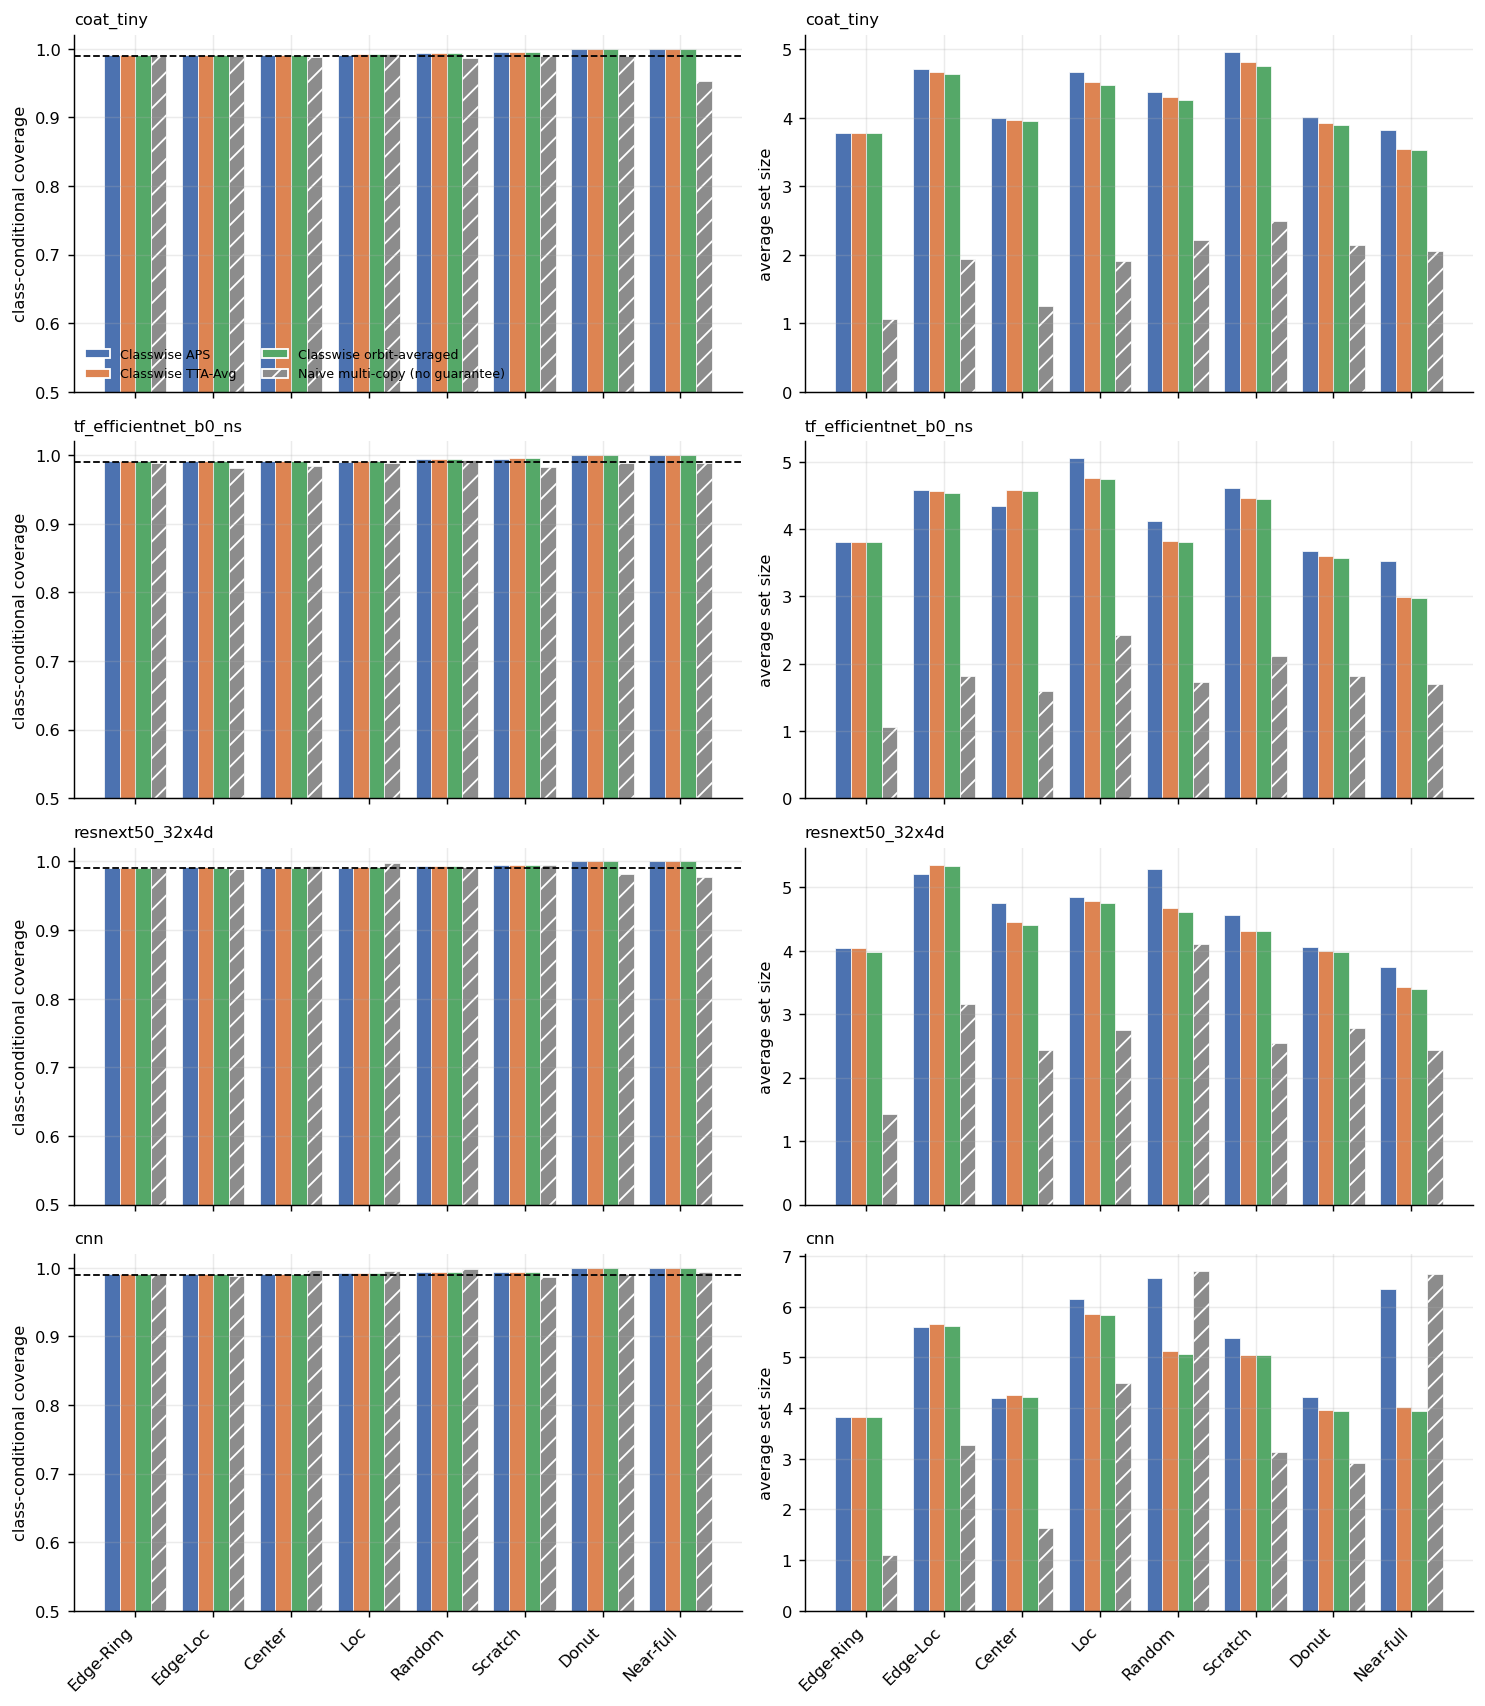

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "legend.frameon": False})

ALPHA_PLOT = ALPHAS[1]

# The naive arm is hatched: it is drawn alongside the others for comparability,
# but it targets no guarantee, and the hatching keeps that visible.
STYLE = {"classwise_plain":    ("#4C72B0", None, "Classwise APS"),
         "classwise_ttaavg":   ("#DD8452", None, "Classwise TTA-Avg"),
         "classwise_orbitavg": ("#55A868", None, "Classwise orbit-averaged"),
         "naive_multicopy":    ("#8C8C8C", "//", "Naive multi-copy (no guarantee)")}

pc = per_class[per_class.alpha == ALPHA_PLOT]
methods = [m for m in STYLE if m in set(pc.method)]      # drawn in STYLE order
plot_models = [m for m in MODELS if m in set(pc.model)]
assert plot_models, f"no rows in per_class for alpha = {ALPHA_PLOT}"

order = list(counts.sort_values(ascending=False).index)
x = np.arange(len(order))
w = 0.8 / len(methods)
offset = (np.arange(len(methods)) - (len(methods) - 1) / 2) * w

# One lower limit for every coverage panel, so rows are comparable and no bar is clipped.
cov_lo = min(0.5, float(np.floor((pc.coverage.min() - 0.02) * 20) / 20))

n = len(plot_models)
fig, axes = plt.subplots(n, 2, figsize=(11.5, 3.3 * n), sharex=True, squeeze=False)

for i, model in enumerate(plot_models):
    d = pc[pc.model == model]
    for j, (col, lab) in enumerate([("coverage", "class-conditional coverage"),
                                    ("avg_size", "average set size")]):
        ax = axes[i, j]
        for k, meth in enumerate(methods):
            colr, hatch, name = STYLE[meth]
            # reindex on the class order: aligned bars, NaN (no bar) for a missing class
            s = d[d.method == meth].set_index("class_name")[col].reindex(order)
            ax.bar(x + offset[k], s.to_numpy(), w, color=colr, hatch=hatch,
                   edgecolor="white", linewidth=0.4)
        ax.set_ylabel(lab)
        ax.set_title(model, loc="left", fontsize=9)
        if col == "coverage":
            ax.axhline(1 - ALPHA_PLOT, color="k", ls="--", lw=1)
            ax.set_ylim(cov_lo, 1.02)

handles = [Patch(facecolor=STYLE[m][0], hatch=STYLE[m][1], edgecolor="white",
                 label=STYLE[m][2]) for m in methods]
axes[0, 0].legend(handles=handles, fontsize=7, ncol=2)

for ax in axes[-1]:
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=45, ha="right")

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_real_per_class.pdf", bbox_inches="tight")
plt.show()

## 8. Numbers for the text

In [16]:
for model in outputs:
    for a in ALPHAS:
        s = main[(main.model == model) & (main.alpha == a)].set_index("method")
        print(f"\n=== {model}, alpha = {a} "
              f"(n_min = {M.finite_threshold_min(a)}) ===")
        for m in ["marginal_plain", "clustered", "classwise_plain",
                  "classwise_ttaavg", "classwise_orbitavg", "naive_multicopy"]:
            if m not in s.index:
                continue
            r = s.loc[m]
            print(f"  {M.DISPLAY_NAMES.get(m, m):30s} "
                  f"WCU {r.WCU:.4f} ({r.WCU_mcse:.4f})  "
                  f"AvgSize {r.AvgSize:.3f}  CovMarg {r.CovMarginal:.4f}  "
                  f"inf thresholds {r.n_inf:.2f}")
        for x, z in COMPARISONS:
            p = pairs[(pairs.model == model) & (pairs.alpha == a)
                      & (pairs.metric == "AvgSize")
                      & (pairs.comparison == f"{z} vs {x}")]
            if len(p):
                p = p.iloc[0]
                print(f"  {z} vs {x}: {p.pct:+.2f}% "
                      f"(mean {p.mean_delta:+.4f}, MCSE {p.mcse:.4f}, "
                      f"t={p.t:.1f}, smaller in {100*p.frac_negative:.0f}%)")

print("\n=== within-orbit variance, directional vs radial ===")
display(piv.round(4))


=== coat_tiny, alpha = 0.1 (n_min = 9) ===
  Marginal APS                   WCU 0.0551 (0.0014)  AvgSize 1.032  CovMarg 0.8999  inf thresholds 0.00
  Clustered APS                  WCU 0.0556 (0.0014)  AvgSize 1.032  CovMarg 0.8998  inf thresholds 0.00
  Classwise APS                  WCU 0.0611 (0.0027)  AvgSize 1.048  CovMarg 0.9021  inf thresholds 0.00
  Classwise TTA-Avg APS          WCU 0.0589 (0.0026)  AvgSize 1.060  CovMarg 0.9019  inf thresholds 0.00
  Classwise orbit-averaged APS   WCU 0.0599 (0.0026)  AvgSize 1.067  CovMarg 0.9018  inf thresholds 0.00
  Naive multi-copy APS           WCU 0.0728 (0.0035)  AvgSize 1.045  CovMarg 0.8999  inf thresholds 0.00
  classwise_orbitavg vs classwise_plain: -1.73% (mean +0.0181, MCSE 0.0007, t=26.4, smaller in 6%)
  classwise_ttaavg vs classwise_plain: -1.06% (mean +0.0111, MCSE 0.0006, t=17.2, smaller in 16%)
  classwise_orbitavg vs classwise_ttaavg: -0.66% (mean +0.0070, MCSE 0.0004, t=16.5, smaller in 17%)

=== coat_tiny, alpha = 0.01

symmetry,directional,radial,ratio
model,,,
cnn,0.0315,0.0103,3.0484
coat_tiny,0.0127,0.0053,2.3862
resnext50_32x4d,0.0219,0.0068,3.2044
tf_efficientnet_b0_ns,0.0230,0.0077,2.9764
